# 📊 Exploratory Data Analysis (EDA)

## 📝 Problem Statement

**Objective**: To analyze Company X's performance from 2014 to 2018, focusing on identifying key revenue and profit drivers across products, sales channels, and geographic regions.

The goal is to:
- Uncover seasonal trends
- Detect performance outliers
- Evaluate alignment with budget targets

## 📌 Scope of This Notebook

This notebook focuses on:
- Visualizing performance across time, products, channels, and regions
- Detecting trends and outliers in revenue and profit
- Comparing actual results with budgets
- Generating actionable business insights

## 🎯 Business Goals

- Optimize pricing and promotions
- Identify high-potential markets
- Minimize risk via diversification

---

> ✅ This notebook uses the cleaned dataset exported from the previous data preparation notebook.


In [2]:
# importing libs
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns

%matplotlib inline

sns.set_theme(style='whitegrid', palette='pastel')  # softer palette
plt.rcParams['figure.figsize'] = (12, 6)            # slightly wider for better visuals
plt.rcParams['axes.titlesize'] = 14                 # increase title size
plt.rcParams['axes.labelsize'] = 12                 # increase label size
plt.rcParams['figure.dpi'] = 120                    # higher resolution visuals

plt.rcParams['font.family'] = 'Arial'

def heading(title):
    print(f"\n📌 {title.upper()}\n{'=' * (len(title) + 2)}")

In [35]:
df = pd.read_excel(r"D:\Data Analytics\End to End Data analytics Project\final_dataset.xlsx")

In [36]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64104 entries, 0 to 64103
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   order_number     64104 non-null  object        
 1   order_date       64104 non-null  datetime64[ns]
 2   customer_names   64104 non-null  object        
 3   channel          64104 non-null  object        
 4   product_name     64104 non-null  object        
 5   order_quantity   64104 non-null  int64         
 6   unit_price       64104 non-null  float64       
 7   revenue          64104 non-null  float64       
 8   total_unit_cost  64104 non-null  float64       
 9   state_code       64104 non-null  object        
 10  county           64104 non-null  object        
 11  state_name       64104 non-null  object        
 12  region           64104 non-null  object        
 13  lat              64104 non-null  float64       
 14  lon              64104 non-null  float

In [37]:
# Filter 2017 records
df_2017 = df[df['order_date'].dt.year == 2017]

In [38]:
df.isnull().sum()

order_number           0
order_date             0
customer_names         0
channel                0
product_name           0
order_quantity         0
unit_price             0
revenue                0
total_unit_cost        0
state_code             0
county                 0
state_name             0
region                 0
lat                    0
lon                    0
budget             48841
dtype: int64

##  Feature Engineering

In this step, we create new features from existing columns to enrich our analysis. These features will help identify seasonality, performance patterns, and customer behavior.


In [39]:
df.head()

,order_number,order_date,customer_names,channel,product_name,order_quantity,unit_price,revenue,total_unit_cost,state_code,county,state_name,region,lat,lon,budget
0,SO - 000225,2014-01-01,Rhynoodle Ltd,Wholesale,Product 27,6,2499.1,14994.6,1824.343,GA,Chatham County,Georgia,South,32.08354,-81.09983,NaN
1,SO - 0003378,2014-01-01,Thoughtmix Ltd,Distributor,Product 20,11,2351.7,25868.7,1269.918,IN,Johnson County,Indiana,Midwest,39.61366,-86.10665,NaN
2,SO - 0005126,2014-01-01,Amerisourc Corp,Wholesale,Product 26,6,978.2,5869.2,684.740,CA,Alameda County,California,West,37.66243,-121.87468,NaN
3,SO - 0005614,2014-01-01,Colgate-Pa Group,Export,Product 7,7,2338.3,16368.1,1028.852,IN,Monroe County,Indiana,Midwest,39.16533,-86.52639,NaN
4,SO - 0005781,2014-01-01,Deseret Group,Wholesale,Product 8,8,2291.4,18331.2,1260.270,CT,Hartford County,Connecticut,Northeast,41.77524,-72.52443,NaN


In [45]:
df['total_cost'] = df['order_quantity'] * df['total_unit_cost']

In [51]:
df['profit'] = df['revenue'] - df['total_cost']

df['profit_margin_pct'] = (df['profit'] / df['revenue']) * 100

In [53]:
df.head()

,order_number,order_date,customer_names,channel,product_name,order_quantity,unit_price,revenue,total_unit_cost,state_code,county,state_name,region,lat,lon,budget,total_cost,profit,profit_margin_pct
0,SO - 000225,2014-01-01,Rhynoodle Ltd,Wholesale,Product 27,6,2499.1,14994.6,1824.343,GA,Chatham County,Georgia,South,32.08354,-81.09983,NaN,10946.058,4048.542,27.0
1,SO - 0003378,2014-01-01,Thoughtmix Ltd,Distributor,Product 20,11,2351.7,25868.7,1269.918,IN,Johnson County,Indiana,Midwest,39.61366,-86.10665,NaN,13969.098,11899.602,46.0
2,SO - 0005126,2014-01-01,Amerisourc Corp,Wholesale,Product 26,6,978.2,5869.2,684.740,CA,Alameda County,California,West,37.66243,-121.87468,NaN,4108.440,1760.760,30.0
3,SO - 0005614,2014-01-01,Colgate-Pa Group,Export,Product 7,7,2338.3,16368.1,1028.852,IN,Monroe County,Indiana,Midwest,39.16533,-86.52639,NaN,7201.964,9166.136,56.0
4,SO - 0005781,2014-01-01,Deseret Group,Wholesale,Product 8,8,2291.4,18331.2,1260.270,CT,Hartford County,Connecticut,Northeast,41.77524,-72.52443,NaN,10082.160,8249.040,45.0


# Feature Engineering extras

To enhance our dataset for deeper analysis and dashboard visualizations, we created the following new features based on the existing cleaned data:

- **Time-based features**  
  Extracted from the `order_date` column to enable trend analysis over years, months, and quarters:  
  `order_year`, `order_month`, `order_quarter`

- **Profitability flags**  
  Created binary flags to quickly filter orders by profitability:  
  - `high_margin_flag`: Indicates orders with profit margin above 30%  
  - `loss_flag`: Indicates orders where profit is negative

- **Revenue per unit**  
  Calculated `revenue_per_unit` by dividing total revenue by order quantity for fair product-level comparison.

- **Region-State combination**  
  Combined `region` and `state_name` into `region_state` for easier geographic grouping in maps and filters.

- **Cumulative revenue**  
  Computed `cumulative_revenue` sorted by `order_date` to visualize business growth over time.

These features will enable rich insights and interactive filtering in the upcoming exploratory data analysis and dashboard development phases.



In [169]:
import pandas as pd

# Create a copy — keeps same rows and same order as original df
df_copy = df.copy()

# Add time-based features
df_copy['order_year'] = df_copy['order_date'].dt.year
df_copy['order_month'] = df_copy['order_date'].dt.month
df_copy['order_quarter'] = df_copy['order_date'].dt.quarter

# Add flags for high margin and loss orders
df_copy['high_margin_flag'] = df_copy['profit_margin_pct'] > 30
df_copy['loss_flag'] = df_copy['profit'] < 0

# Revenue per unit
df_copy['revenue_per_unit'] = df_copy['revenue'] / df_copy['order_quantity']

# Combine region and state_name for geo-level grouping
df_copy['region_state'] = df_copy['region'] + ' - ' + df_copy['state_name']

# Cumulative revenue — keep row order same as original
df_copy['cumulative_revenue'] = df_copy['revenue'].cumsum()

# Optional: Format floats for clean display
pd.set_option('display.float_format', '{:.2f}'.format)

# Done! Index and row order are same as original df



In [171]:
df_copy.head()

,order_number,order_date,customer_names,channel,product_name,order_quantity,unit_price,revenue,total_unit_cost,state_code,county,state_name,region,lat,lon,budget,total_cost,profit,profit_margin_pct,order_year,order_month,order_quarter,high_margin_flag,loss_flag,revenue_per_unit,region_state,cumulative_revenue
0,SO - 000225,2014-01-01,Rhynoodle Ltd,Wholesale,Product 27,6,2499.10,14994.60,1824.34,GA,Chatham County,Georgia,South,32.08,-81.10,NaN,10946.06,4048.54,27.00,2014,1,1,False,False,2499.10,South - Georgia,14994.60
1,SO - 0003378,2014-01-01,Thoughtmix Ltd,Distributor,Product 20,11,2351.70,25868.70,1269.92,IN,Johnson County,Indiana,Midwest,39.61,-86.11,NaN,13969.10,11899.60,46.00,2014,1,1,True,False,2351.70,Midwest - Indiana,40863.30
2,SO - 0005126,2014-01-01,Amerisourc Corp,Wholesale,Product 26,6,978.20,5869.20,684.74,CA,Alameda County,California,West,37.66,-121.87,NaN,4108.44,1760.76,30.00,2014,1,1,False,False,978.20,West - California,46732.50
3,SO - 0005614,2014-01-01,Colgate-Pa Group,Export,Product 7,7,2338.30,16368.10,1028.85,IN,Monroe County,Indiana,Midwest,39.17,-86.53,NaN,7201.96,9166.14,56.00,2014,1,1,True,False,2338.30,Midwest - Indiana,63100.60
4,SO - 0005781,2014-01-01,Deseret Group,Wholesale,Product 8,8,2291.40,18331.20,1260.27,CT,Hartford County,Connecticut,Northeast,41.78,-72.52,NaN,10082.16,8249.04,45.00,2014,1,1,True,False,2291.40,Northeast - Connecticut,81431.80


In [175]:
pd.set_option('display.max_columns', None)
df_copy

,order_number,order_date,customer_names,channel,product_name,order_quantity,unit_price,revenue,total_unit_cost,state_code,county,state_name,region,lat,lon,budget,total_cost,profit,profit_margin_pct,order_year,order_month,order_quarter,high_margin_flag,loss_flag,revenue_per_unit,region_state,cumulative_revenue
0,SO - 000225,2014-01-01,Rhynoodle Ltd,Wholesale,Product 27,6,2499.10,14994.60,1824.34,GA,Chatham County,Georgia,South,32.08,-81.10,NaN,10946.06,4048.54,27.00,2014,1,1,False,False,2499.10,South - Georgia,14994.60
1,SO - 0003378,2014-01-01,Thoughtmix Ltd,Distributor,Product 20,11,2351.70,25868.70,1269.92,IN,Johnson County,Indiana,Midwest,39.61,-86.11,NaN,13969.10,11899.60,46.00,2014,1,1,True,False,2351.70,Midwest - Indiana,40863.30
2,SO - 0005126,2014-01-01,Amerisourc Corp,Wholesale,Product 26,6,978.20,5869.20,684.74,CA,Alameda County,California,West,37.66,-121.87,NaN,4108.44,1760.76,30.00,2014,1,1,False,False,978.20,West - California,46732.50
3,SO - 0005614,2014-01-01,Colgate-Pa Group,Export,Product 7,7,2338.30,16368.10,1028.85,IN,Monroe County,Indiana,Midwest,39.17,-86.53,NaN,7201.96,9166.14,56.00,2014,1,1,True,False,2338.30,Midwest - Indiana,63100.60
4,SO - 0005781,2014-01-01,Deseret Group,Wholesale,Product 8,8,2291.40,18331.20,1260.27,CT,Hartford County,Connecticut,Northeast,41.78,-72.52,NaN,10082.16,8249.04,45.00,2014,1,1,True,False,2291.40,Northeast - Connecticut,81431.80
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
64099,SO - 0007573,2018-02-28,Dazzlesphe Corp,Wholesale,Product 26,12,1815.70,21788.40,980.48,PA,Bucks County,Pennsylvania,Northeast,40.16,-74.83,NaN,11765.74,10022.66,46.00,2018,2,1,True,False,1815.70,Northeast - Pennsylvania,1235884525.90
64100,SO - 0007706,2018-02-28,Yombu Corp,Export,Product 21,6,864.30,5185.80,579.08,IL,Cook County,Illinois,Midwest,42.11,-88.03,NaN,3474.49,1711.31,33.00,2018,2,1,True,False,864.30,Midwest - Illinois,1235889711.70
64101,SO - 0007718,2018-02-28,Bath Group,Distributor,Product 13,11,3953.00,43483.00,2648.51,FL,Broward County,Florida,South,26.24,-80.21,NaN,29133.61,14349.39,33.00,2018,2,1,True,False,3953.00,South - Florida,1235933194.70
64102,SO - 0008084,2018-02-28,Linklinks Ltd,Distributor,Product 20,7,3959.70,27717.90,2930.18,NY,Erie County,New York,Northeast,42.91,-78.74,NaN,20511.25,7206.65,26.00,2018,2,1,False,False,3959.70,Northeast - New York,1235960912.60


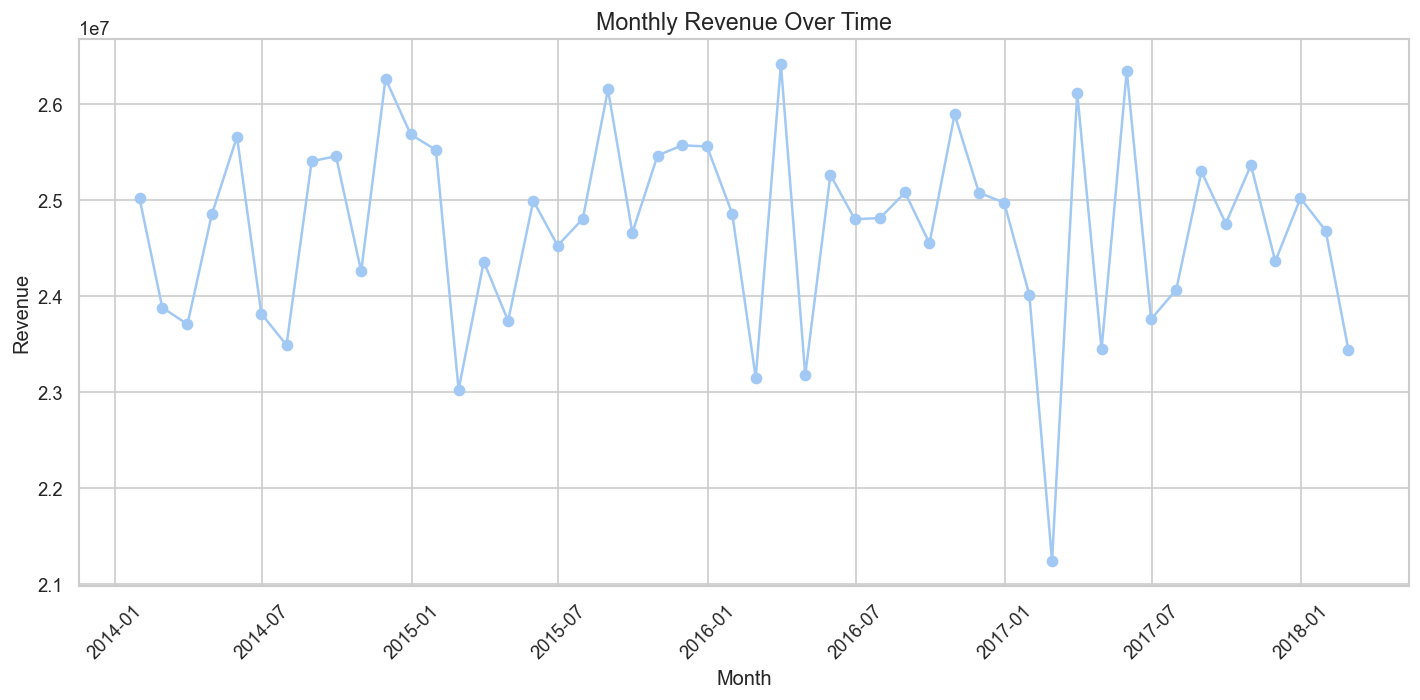

In [177]:
import matplotlib.pyplot as plt

# Ensure order_date is datetime
df['order_date'] = pd.to_datetime(df['order_date'])

# Group by month and sum revenue (monthly total revenue)
monthly_revenue = df.groupby(pd.Grouper(key='order_date', freq='ME'))['revenue'].sum()

# Plot line chart
plt.figure(figsize=(12,6))
plt.plot(monthly_revenue.index, monthly_revenue.values, marker='o', linestyle='-')
plt.title('Monthly Revenue Over Time')
plt.xlabel('Month')
plt.ylabel('Revenue')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



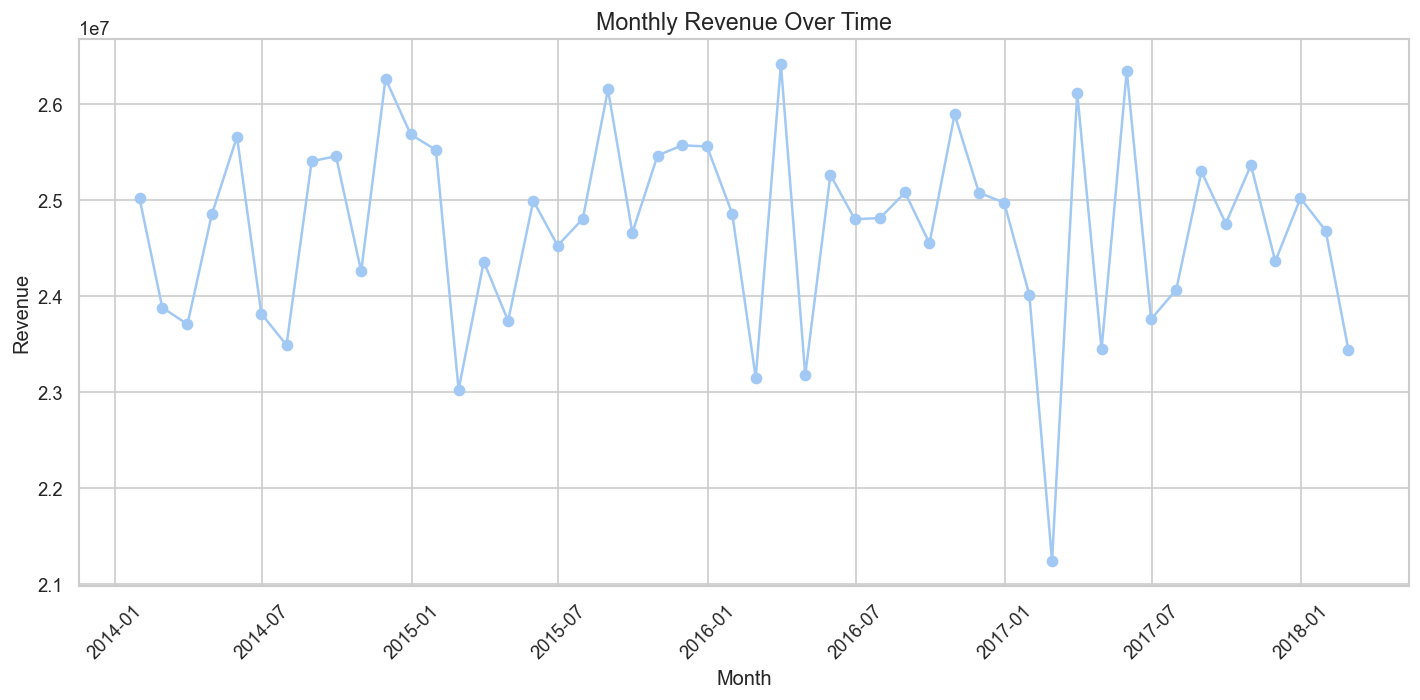

In [86]:
import matplotlib.pyplot as plt

# Ensure order_date is datetime
df_copy['order_date'] = pd.to_datetime(df['order_date'])

# Group by month and sum revenue (monthly total revenue)
monthly_revenue = df.groupby(pd.Grouper(key='order_date', freq='ME'))['revenue'].sum()

# Plot line chart
plt.figure(figsize=(12,6))
plt.plot(monthly_revenue.index, monthly_revenue.values, marker='o', linestyle='-')
plt.title('Monthly Revenue Over Time')
plt.xlabel('Month')
plt.ylabel('Revenue')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


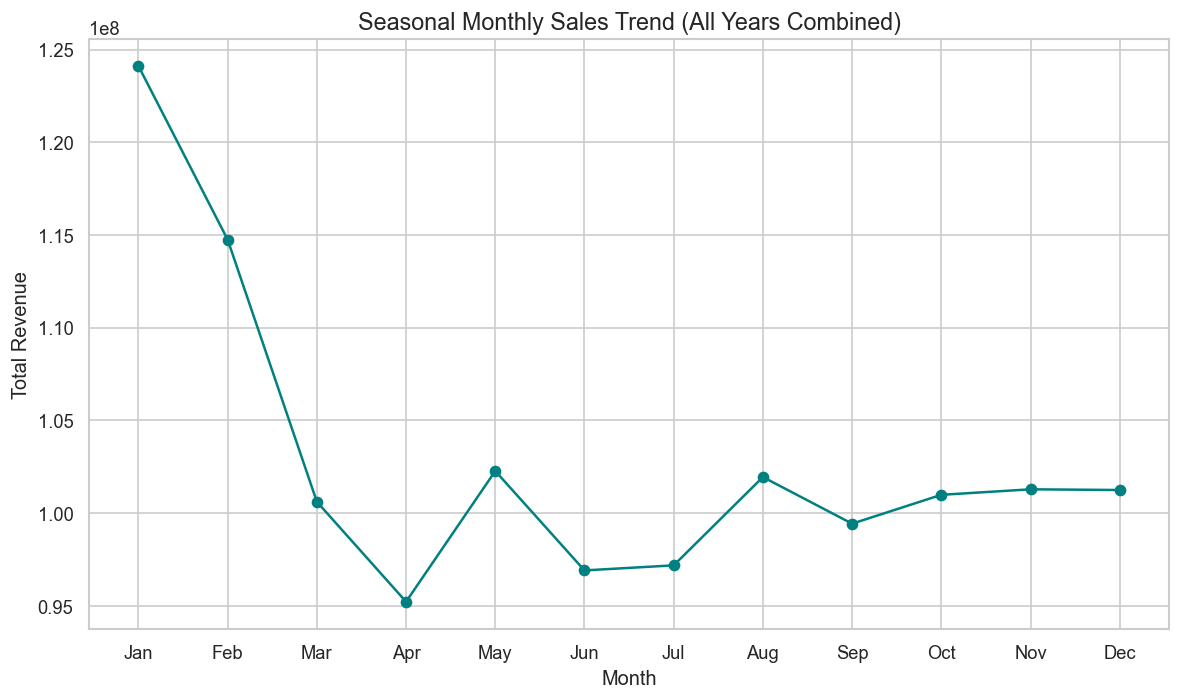

In [179]:
import pandas as pd
import matplotlib.pyplot as plt

# Ensure datetime format
df_copy['order_date'] = pd.to_datetime(df_copy['order_date'])

# Extract calendar month (1 to 12)
df_copy['month'] = df_copy['order_date'].dt.month

# Group by month and sum revenue (aggregated across all years)
monthly_seasonality = df_copy.groupby('month')['revenue'].sum()

# Optional: Get month names for better x-axis
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

# Plot
plt.figure(figsize=(10, 6))
plt.plot(month_names, monthly_seasonality.values, marker='o', linestyle='-', color='teal')
plt.title('Seasonal Monthly Sales Trend (All Years Combined)')
plt.xlabel('Month')
plt.ylabel('Total Revenue')
plt.grid(True)
plt.tight_layout()
plt.show()




In [181]:
df_copy.head()

,order_number,order_date,customer_names,channel,product_name,order_quantity,unit_price,revenue,total_unit_cost,state_code,county,state_name,region,lat,lon,budget,total_cost,profit,profit_margin_pct,order_year,order_month,order_quarter,high_margin_flag,loss_flag,revenue_per_unit,region_state,cumulative_revenue,month
0,SO - 000225,2014-01-01,Rhynoodle Ltd,Wholesale,Product 27,6,2499.10,14994.60,1824.34,GA,Chatham County,Georgia,South,32.08,-81.10,NaN,10946.06,4048.54,27.00,2014,1,1,False,False,2499.10,South - Georgia,14994.60,1
1,SO - 0003378,2014-01-01,Thoughtmix Ltd,Distributor,Product 20,11,2351.70,25868.70,1269.92,IN,Johnson County,Indiana,Midwest,39.61,-86.11,NaN,13969.10,11899.60,46.00,2014,1,1,True,False,2351.70,Midwest - Indiana,40863.30,1
2,SO - 0005126,2014-01-01,Amerisourc Corp,Wholesale,Product 26,6,978.20,5869.20,684.74,CA,Alameda County,California,West,37.66,-121.87,NaN,4108.44,1760.76,30.00,2014,1,1,False,False,978.20,West - California,46732.50,1
3,SO - 0005614,2014-01-01,Colgate-Pa Group,Export,Product 7,7,2338.30,16368.10,1028.85,IN,Monroe County,Indiana,Midwest,39.17,-86.53,NaN,7201.96,9166.14,56.00,2014,1,1,True,False,2338.30,Midwest - Indiana,63100.60,1
4,SO - 0005781,2014-01-01,Deseret Group,Wholesale,Product 8,8,2291.40,18331.20,1260.27,CT,Hartford County,Connecticut,Northeast,41.78,-72.52,NaN,10082.16,8249.04,45.00,2014,1,1,True,False,2291.40,Northeast - Connecticut,81431.80,1


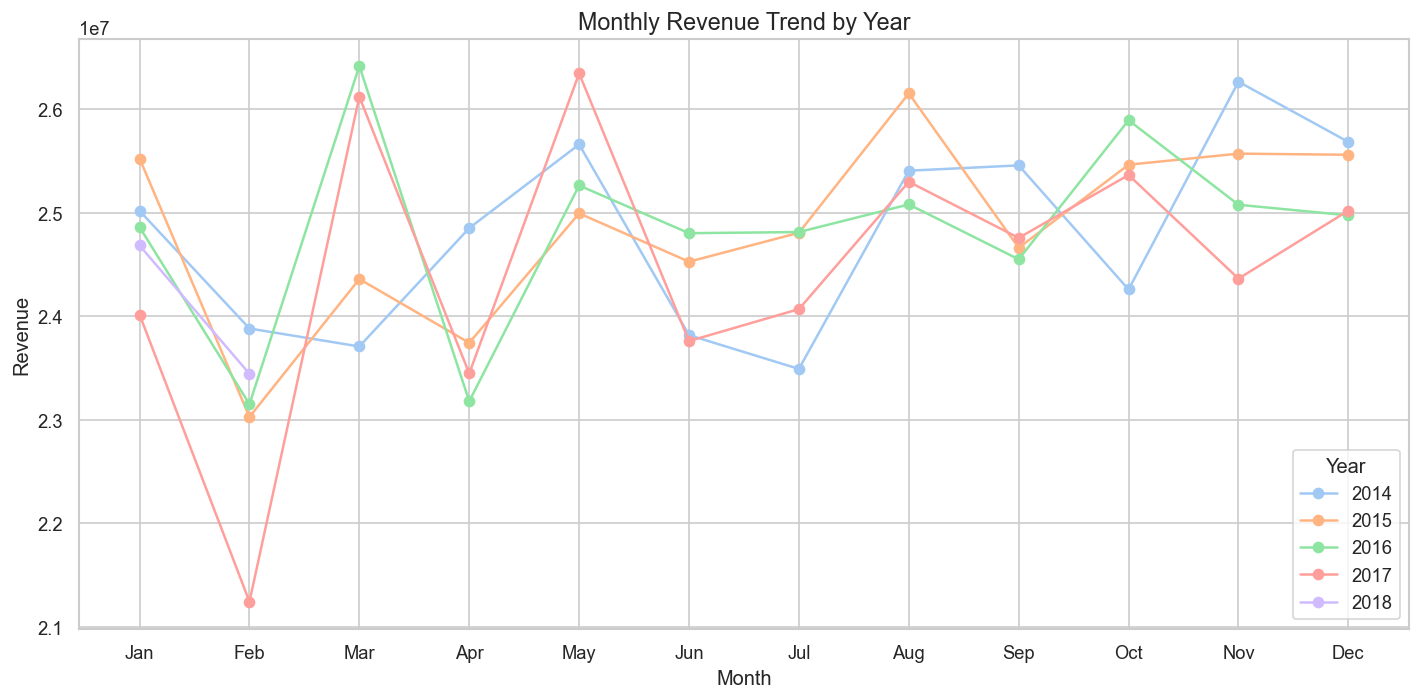

In [186]:
import pandas as pd
import matplotlib.pyplot as plt

# Ensure datetime format
df_copy['order_date'] = pd.to_datetime(df_copy['order_date'])

# Extract year and month
df_copy['year'] = df_copy['order_date'].dt.year
df_copy['month'] = df_copy['order_date'].dt.month

# Group by year and month, summing revenue
monthly_revenue_by_year = df_copy.groupby(['year', 'month'])['revenue'].sum().unstack(0)  # month x year

# Optional: Month names
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
monthly_revenue_by_year.index = month_names

# Plot
plt.figure(figsize=(12, 6))
for year in monthly_revenue_by_year.columns:
    plt.plot(month_names, monthly_revenue_by_year[year], marker='o', label=str(year))

plt.title("Monthly Revenue Trend by Year")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.grid(True)
plt.legend(title="Year")
plt.tight_layout()
plt.show()


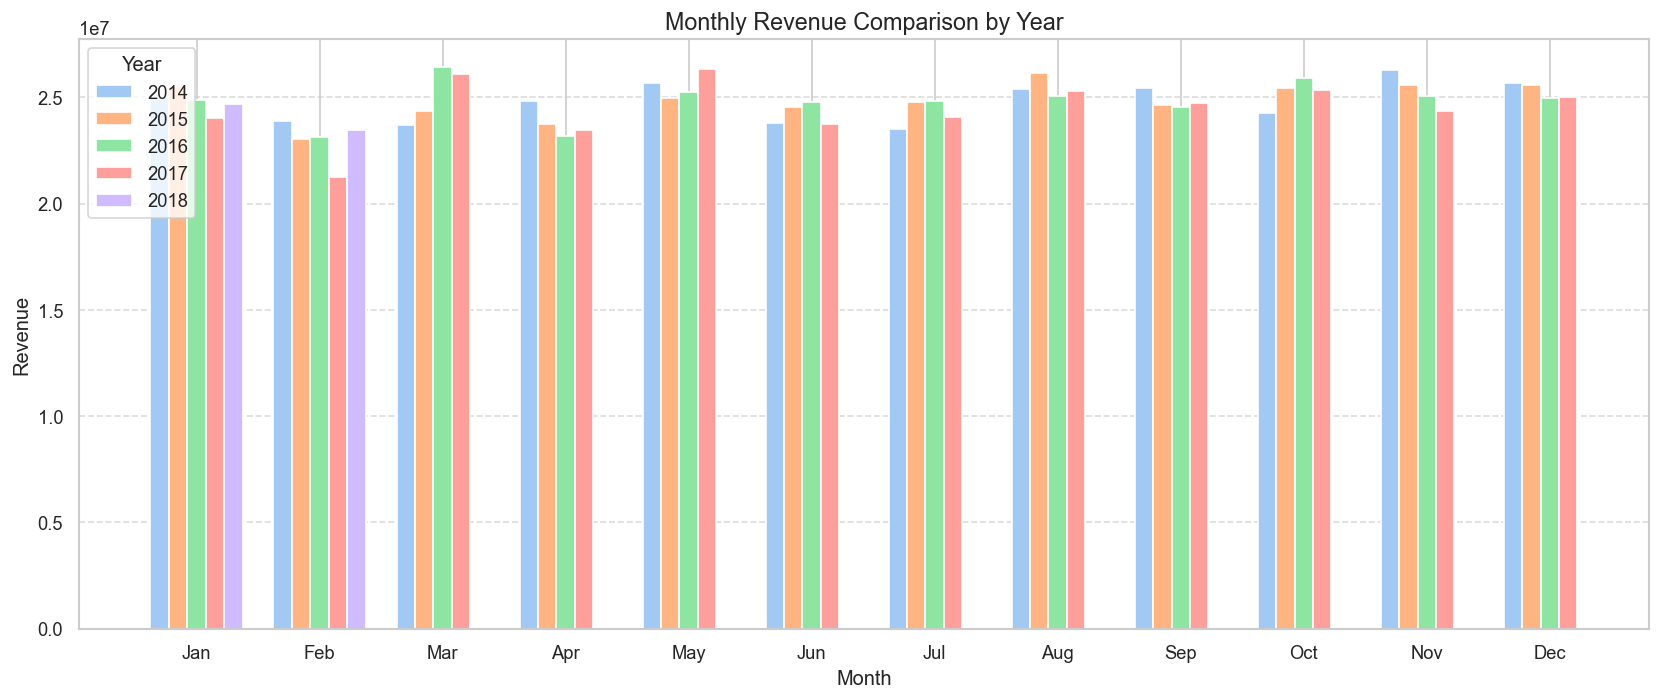

In [188]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Ensure datetime format
df_copy['order_date'] = pd.to_datetime(df_copy['order_date'])

# Extract year and month
df_copy['year'] = df_copy['order_date'].dt.year
df_copy['month'] = df_copy['order_date'].dt.month

# Group by year and month, sum revenue
monthly_revenue_by_year = df_copy.groupby(['month', 'year'])['revenue'].sum().unstack()  # rows: months, columns: years

# Month names for x-axis
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
monthly_revenue_by_year.index = month_names

# Plot grouped bars
bar_width = 0.15
months = np.arange(len(month_names))
years = monthly_revenue_by_year.columns

plt.figure(figsize=(14, 6))

for i, year in enumerate(years):
    plt.bar(months + i * bar_width, monthly_revenue_by_year[year], width=bar_width, label=str(year))

plt.xticks(months + bar_width * (len(years) - 1) / 2, month_names)
plt.title('Monthly Revenue Comparison by Year')
plt.xlabel('Month')
plt.ylabel('Revenue')
plt.legend(title='Year')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


In [189]:
print("Years in dataset:", monthly_revenue_by_year.columns.tolist())
print("Missing values by year:\n", monthly_revenue_by_year.isna().sum())


Years in dataset: [2014, 2015, 2016, 2017, 2018]
Missing values by year:
 year
2014     0
2015     0
2016     0
2017     0
2018    10
dtype: int64


## this shows why we were getting wrong responce , jan,feb were the only data from 2018.


### 📊 Seasonal Monthly Sales Trend (Excluding 2018)

#### ✅ Step 1: Remove Incomplete Year (2018)
Remove records from 2018 since only Jan & Feb data is available, which can mislead seasonal patterns.

#### ✅ Step 2: Extract Calendar Month
Create a `month` column from `order_date` to group by calendar months (Jan–Dec).

#### ✅ Step 3: Aggregate Revenue
Group by `month` and sum `revenue` across all years (excluding 2018).

#### ✅ Step 4: Plot Seasonality
Plot a line chart to visualize how revenue typically varies month to month across the year.


In [194]:
# Ensure 'order_date' is in datetime format
df_copy['order_date'] = pd.to_datetime(df_copy['order_date'])

# Extract year from 'order_date'
df_copy['year'] = df_copy['order_date'].dt.year

# Create new DataFrame excluding 2018
df_copy2 = df_copy[df_copy['year'] != 2018].copy()

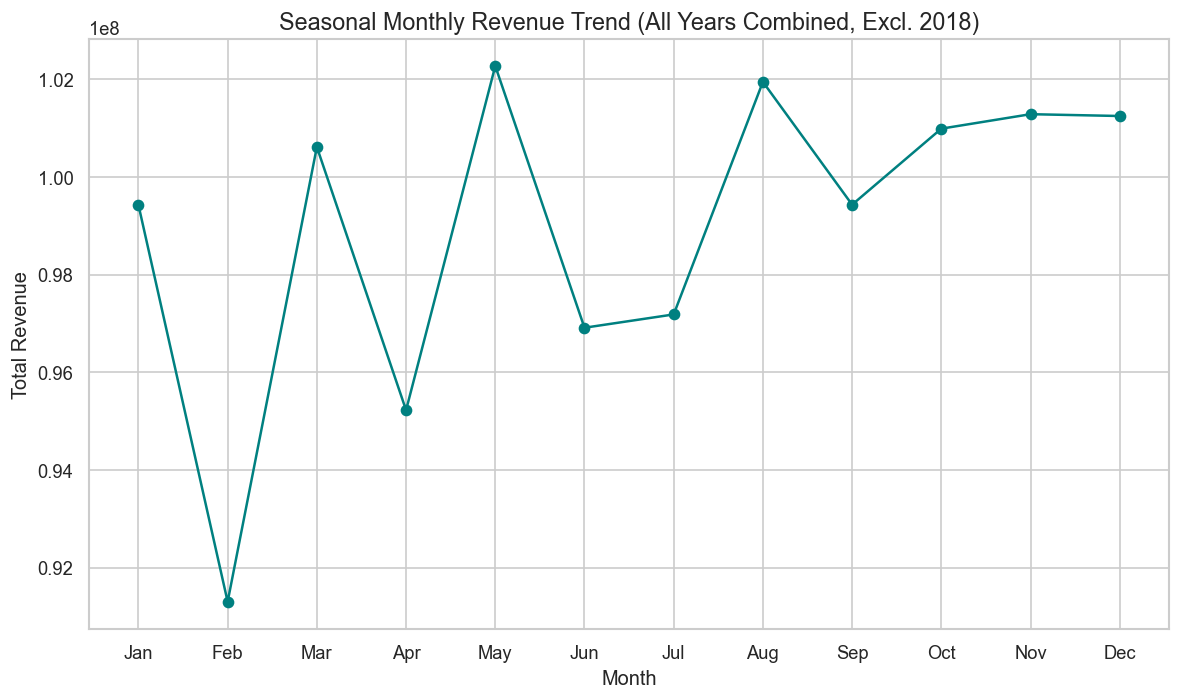

In [196]:
import pandas as pd
import matplotlib.pyplot as plt

# Ensure datetime format again (in case not already set)
df_copy2['order_date'] = pd.to_datetime(df_copy2['order_date'])

# Extract month
df_copy2['month'] = df_copy2['order_date'].dt.month

# Group by calendar month and sum revenue across all years
monthly_seasonality = df_copy2.groupby('month')['revenue'].sum()

# Optional: Add month names for prettier x-axis
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
monthly_seasonality.index = month_names

# Plot the seasonal trend
plt.figure(figsize=(10, 6))
plt.plot(month_names, monthly_seasonality.values, marker='o', linestyle='-', color='teal')
plt.title('Seasonal Monthly Revenue Trend (All Years Combined, Excl. 2018)')
plt.xlabel('Month')
plt.ylabel('Total Revenue')
plt.grid(True)
plt.tight_layout()
plt.show()


In [198]:
# Group by 'product_name' and sum revenue
top_products = df_copy2.groupby('product_name')['revenue'].sum().sort_values(ascending=False).head(10)

# Display result
print(top_products)


product_name
Product 26   112454990.90
Product 25   105715762.40
Product 13    75190019.70
Product 14    72516666.10
Product 5     68032711.20
Product 15    64933726.70
Product 2     54976803.10
Product 4     54558669.50
Product 1     53678832.20
Product 3     49935227.30
Name: revenue, dtype: float64


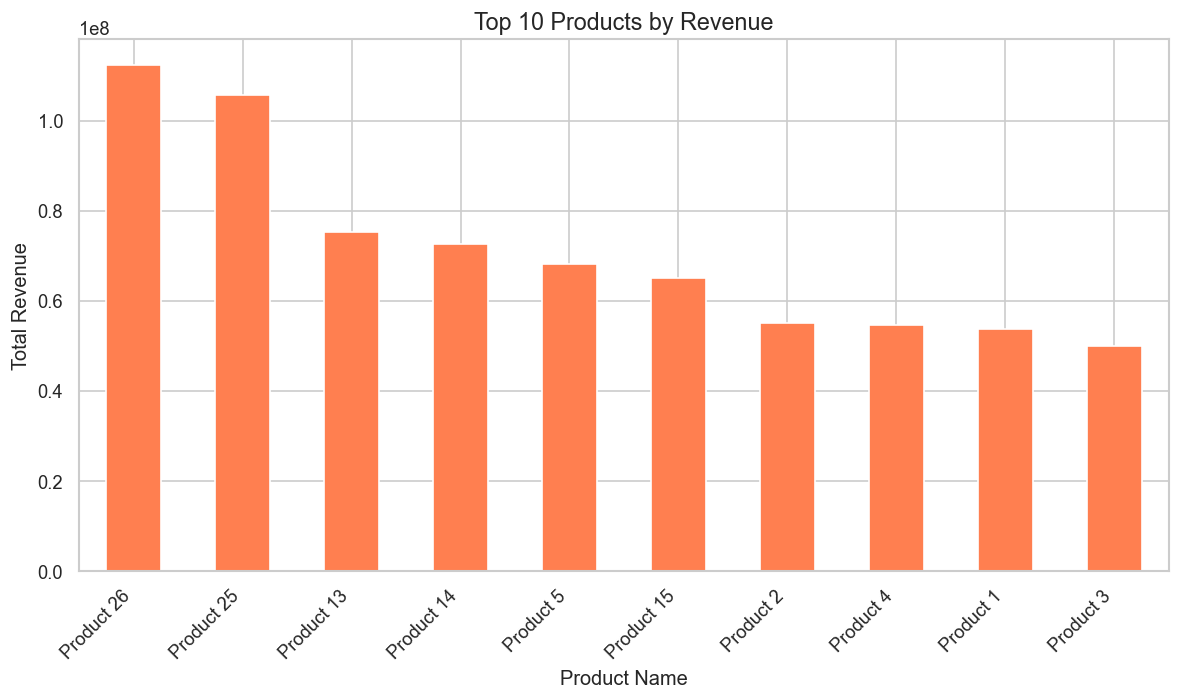

In [200]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
top_products.plot(kind='bar', color='coral')
plt.title('Top 10 Products by Revenue')
plt.xlabel('Product Name')
plt.ylabel('Total Revenue')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


In [202]:
# Group by product_name and sum profit
top_products_profit = df_copy2.groupby('product_name')['profit'].sum().sort_values(ascending=False).head(10)

# Display result
print(top_products_profit)


product_name
Product 26   42521347.53
Product 25   40186493.87
Product 13   27574419.43
Product 14   25893334.76
Product 5    25479991.59
Product 15   23908262.25
Product 1    20595131.14
Product 4    20585140.64
Product 2    19693022.70
Product 3    18438173.81
Name: profit, dtype: float64


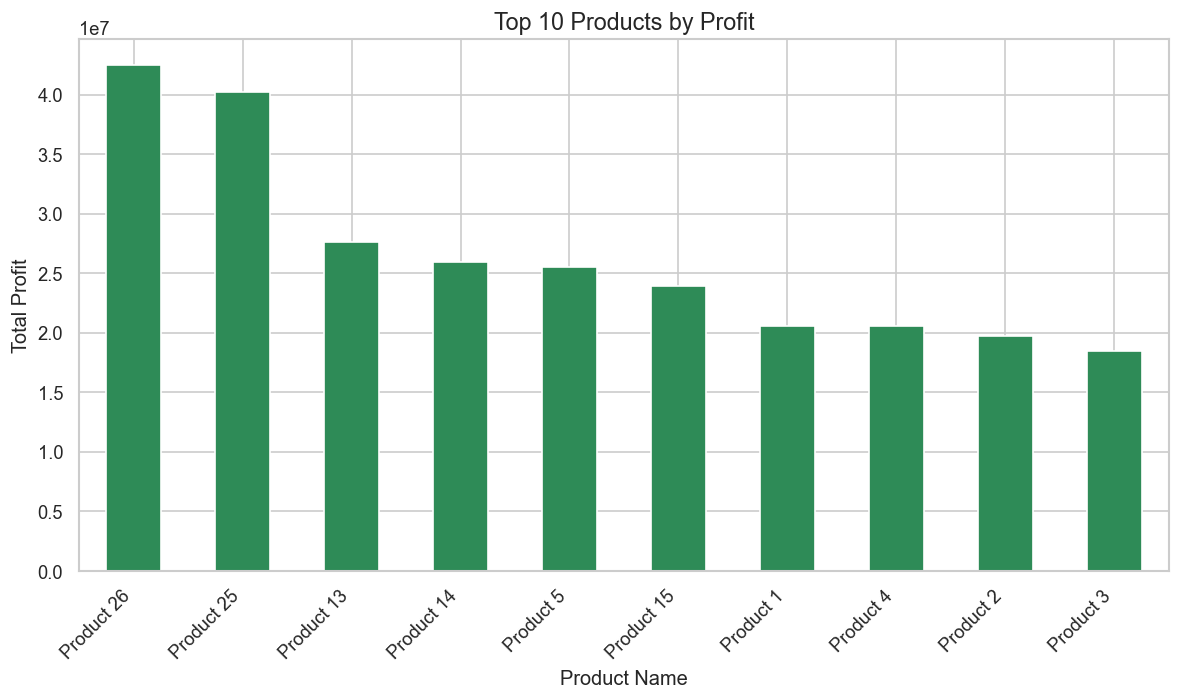

In [204]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
top_products_profit.plot(kind='bar', color='seagreen')
plt.title('Top 10 Products by Profit')
plt.xlabel('Product Name')
plt.ylabel('Total Profit')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


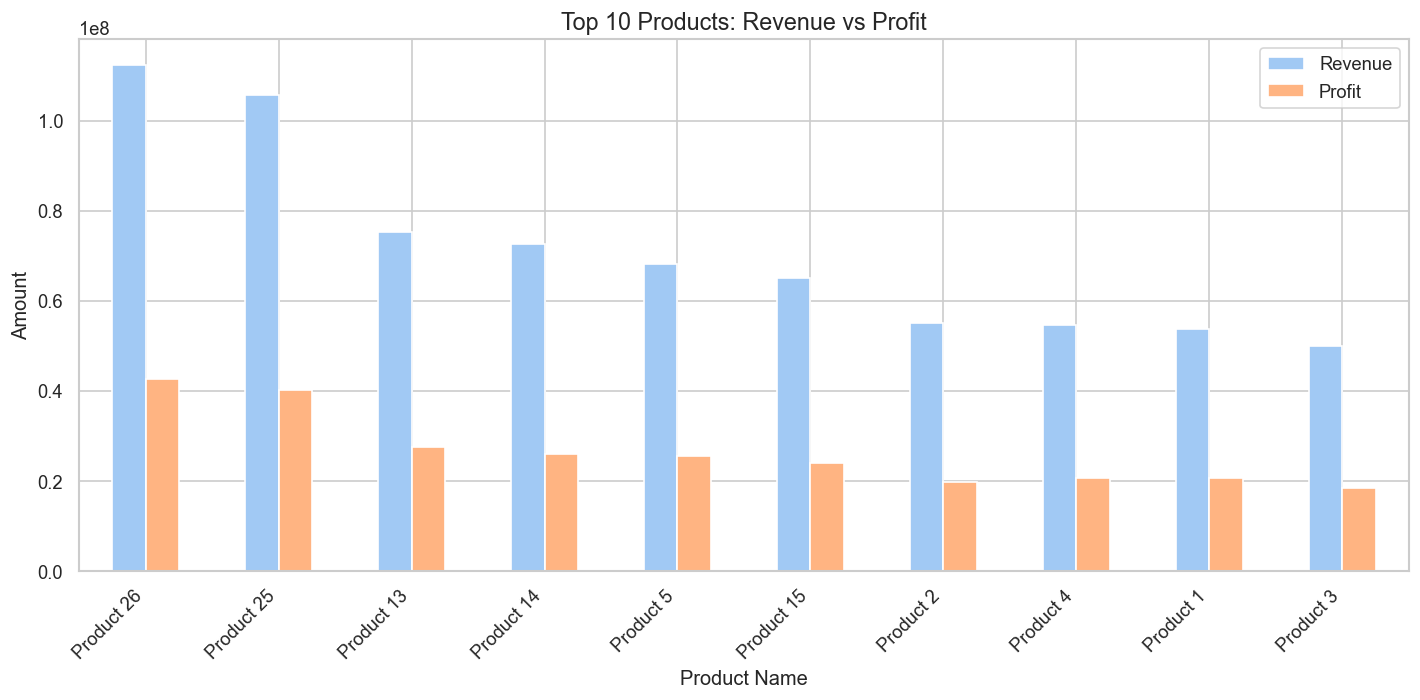

In [220]:
import pandas as pd
import matplotlib.pyplot as plt

# DataFrame is named df and has columns: 'product_name', 'revenue', 'profit'

# Get top 10 products by revenue
top_products = df_copy2.groupby('product_name')[['revenue', 'profit']].sum().sort_values(by='revenue', ascending=False).head(10)


# Plot
top_products.plot(kind='bar', figsize=(12,6))

plt.title('Top 10 Products: Revenue vs Profit')
plt.xlabel('Product Name')
plt.ylabel('Amount')
plt.xticks(rotation=45, ha='right')
plt.legend(['Revenue', 'Profit'])
plt.tight_layout()
plt.show()



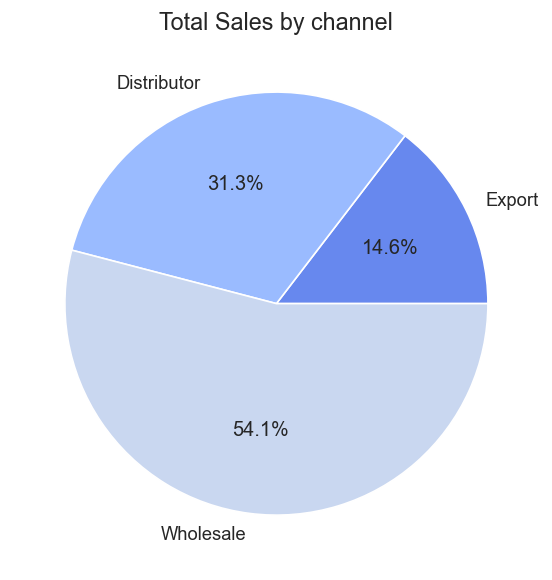

In [218]:
# Sales by Channel 

chan_sales = df_copy2.groupby('channel')['revenue'].sum().sort_values(ascending = True)

plt.figure(figsize=(5,5))

plt.pie(
    chan_sales.values,
    labels = chan_sales.index,
    autopct = '%1.1f%%',
    colors = sns.color_palette('coolwarm')
)

plt.title('Total Sales by channel')
plt.tight_layout()
plt.show()

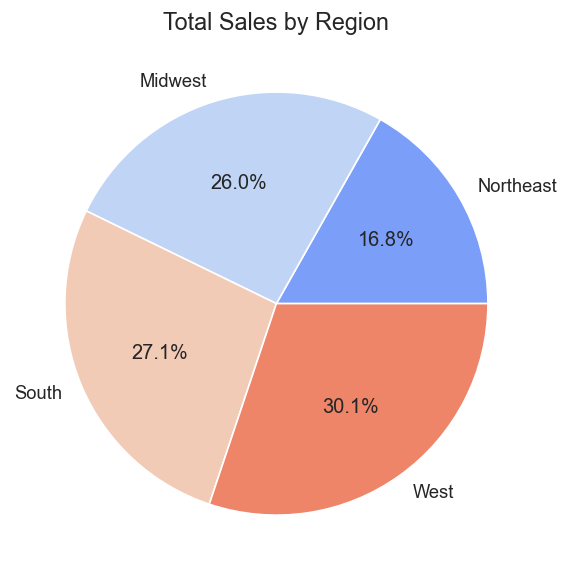

In [151]:

region_sales = df_copy2.groupby('region')['revenue'].sum().sort_values(ascending=True)

plt.figure(figsize=(5,5))

plt.pie(
    region_sales.values,
    labels=region_sales.index,
    autopct='%1.1f%%',
    colors=sns.color_palette('coolwarm', len(region_sales))  
)

plt.title('Total Sales by Region')
plt.tight_layout()
plt.show()


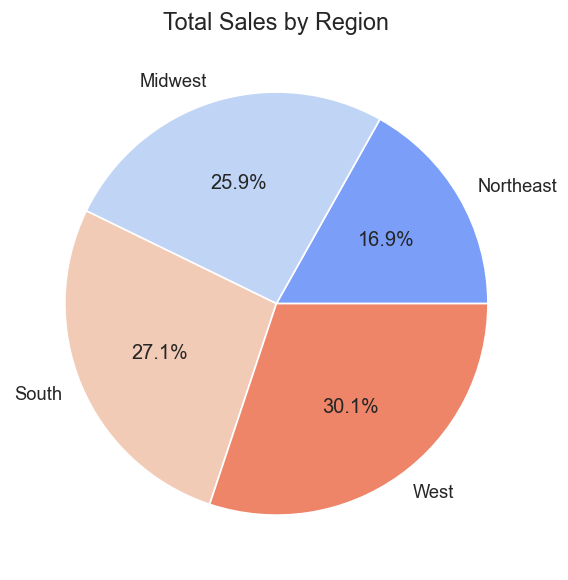

In [222]:
region_sales = df_copy.groupby('region')['revenue'].sum().sort_values(ascending=True)

plt.figure(figsize=(5,5))

plt.pie(
    region_sales.values,
    labels=region_sales.index,
    autopct='%1.1f%%',
    colors=sns.color_palette('coolwarm', len(region_sales))  
)

plt.title('Total Sales by Region')
plt.tight_layout()
plt.show()


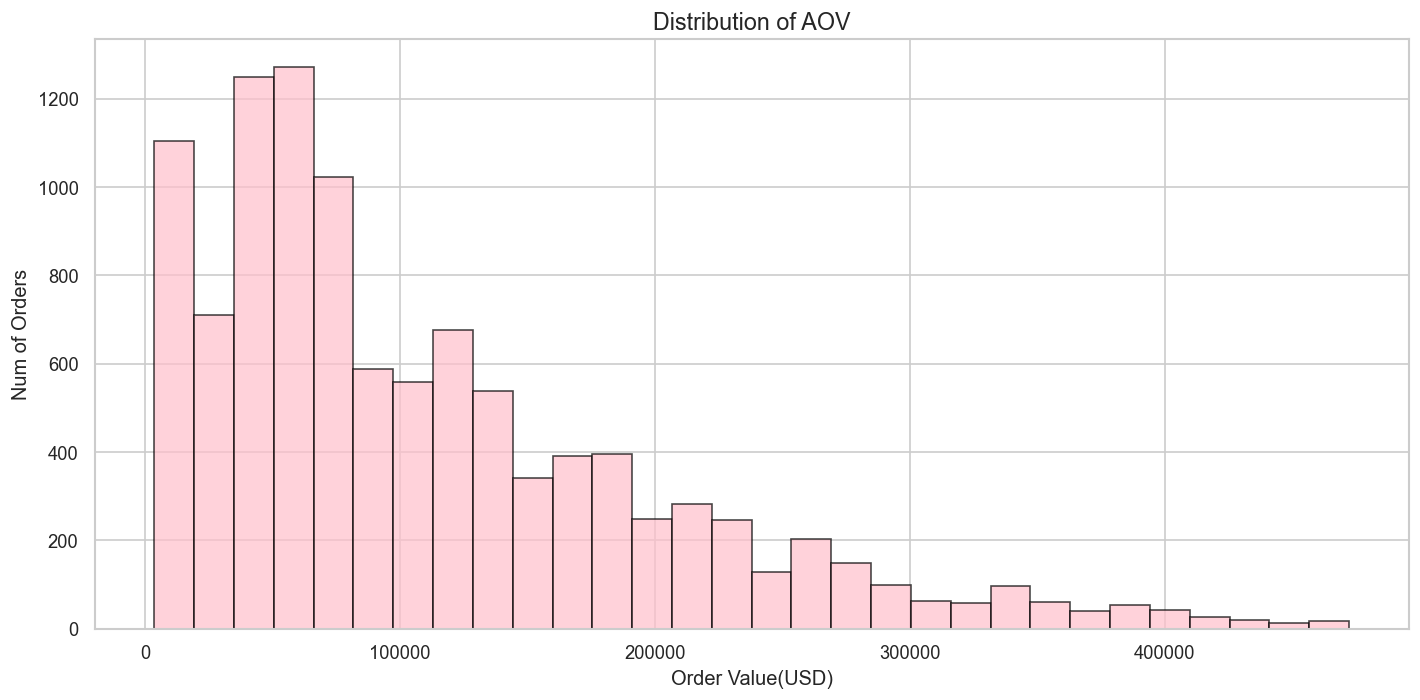

In [234]:
# Average Order Value(AOV) Disrtributionn 

aov = df_copy2.groupby('order_number')['revenue'].sum()


plt.hist(aov, bins=30, color='pink', alpha=0.7, edgecolor='black')
plt.title('Distribution of AOV')
plt.xlabel('Order Value(USD)')
plt.ylabel('Num of Orders')
plt.tight_layout()

plt.show()

In [236]:
# unit price dist. per product
# top10 states by revenue and order count
# top and bottom 10 customers by revenue 
# customer segmentation: revenue vs profit margin
# corr heatmap

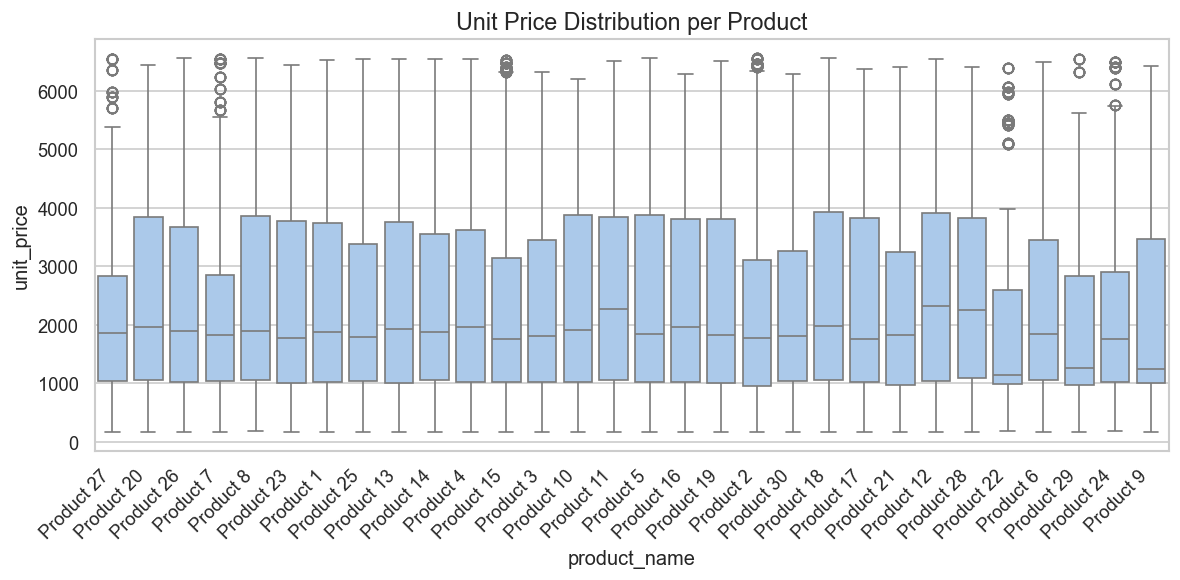

In [266]:
plt.figure(figsize=(10,5))
sns.boxplot(data=df_copy2, x='product_name', y='unit_price')
plt.title('Unit Price Distribution per Product')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


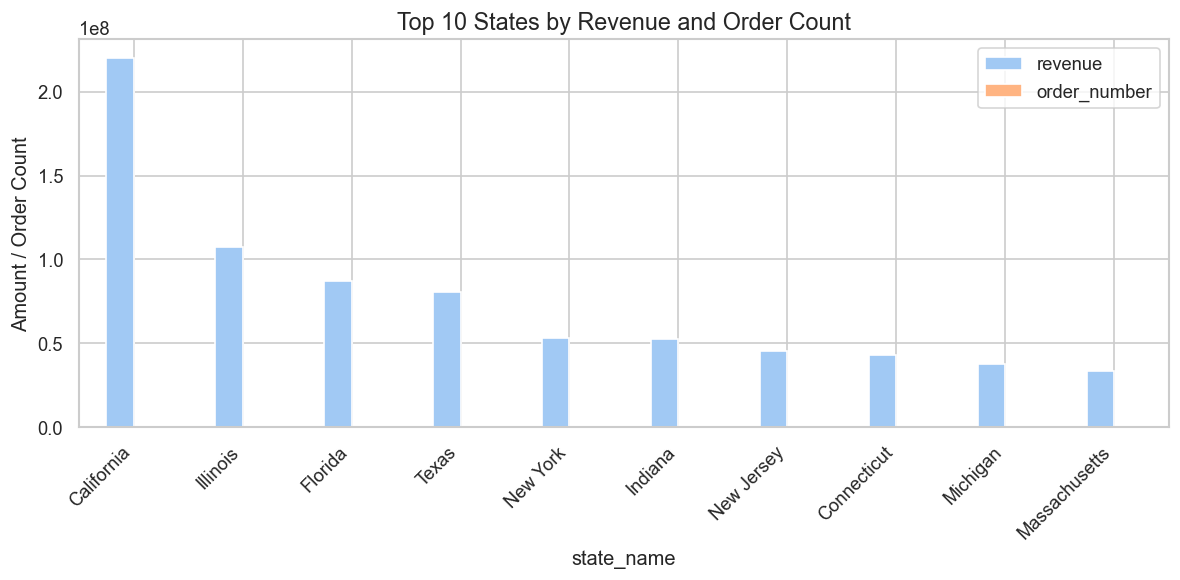

In [264]:
top_states = df_copy2.groupby('state_name')[['revenue', 'order_number']].agg({
    'revenue': 'sum',
    'order_number': 'nunique'
}).sort_values(by='revenue', ascending=False).head(10)

top_states.plot(kind='bar', figsize=(10,5))
plt.title('Top 10 States by Revenue and Order Count')
plt.ylabel('Amount / Order Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


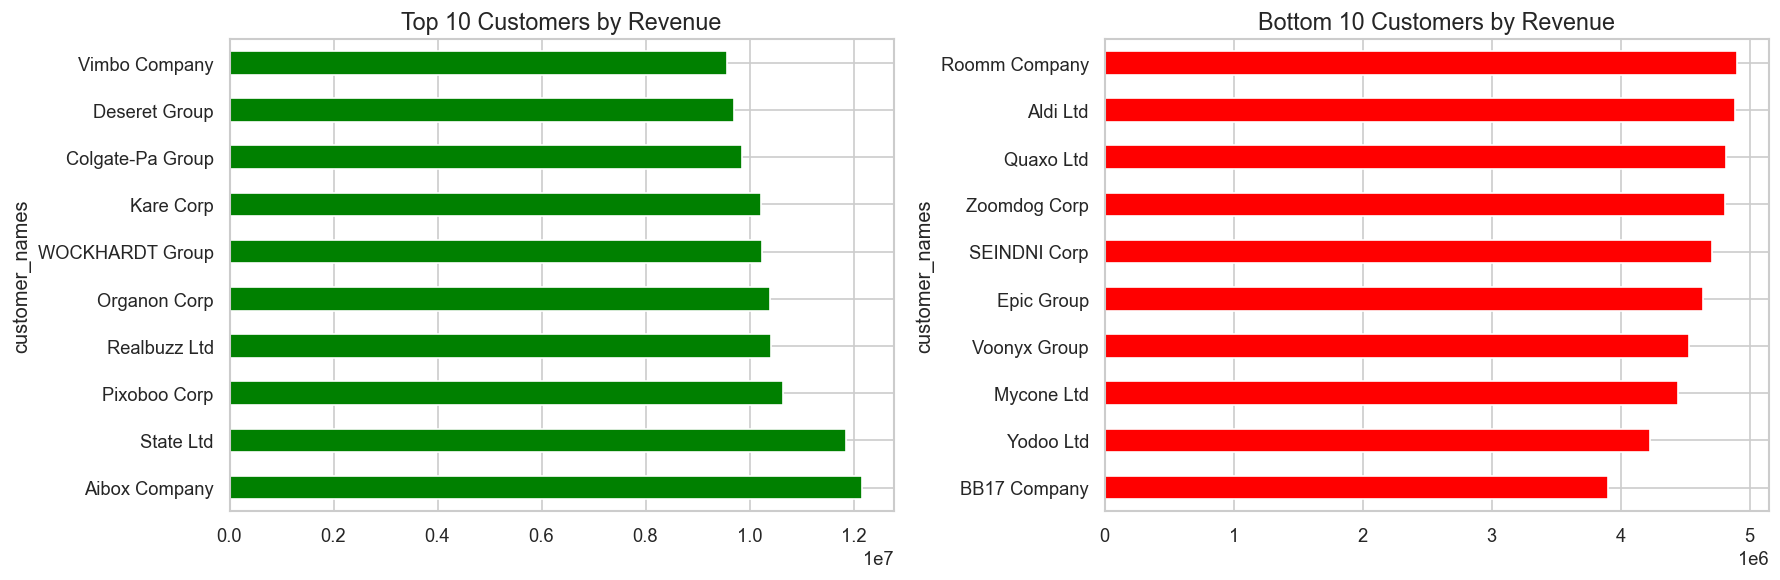

In [262]:
cust_rev = df_copy2.groupby('customer_names')['revenue'].sum()

top_customers = cust_rev.sort_values(ascending=False).head(10)
bottom_customers = cust_rev.sort_values().head(10)

# Plot both
fig, axs = plt.subplots(1, 2, figsize=(15, 5))

top_customers.plot(kind='barh', ax=axs[0], color='green')
axs[0].set_title('Top 10 Customers by Revenue')

bottom_customers.plot(kind='barh', ax=axs[1], color='red')
axs[1].set_title('Bottom 10 Customers by Revenue')

plt.tight_layout()
plt.show()


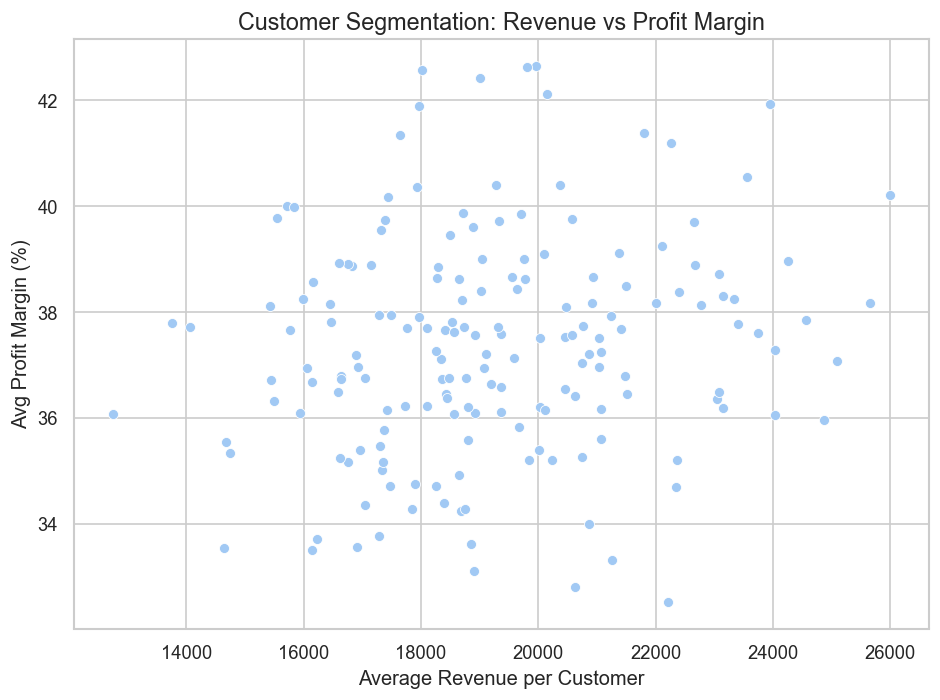

In [260]:
cust_seg = df_copy2.groupby('customer_names')[['revenue', 'profit_margin_pct']].mean().reset_index()

plt.figure(figsize=(8,6))
sns.scatterplot(data=cust_seg, x='revenue', y='profit_margin_pct')
plt.title('Customer Segmentation: Revenue vs Profit Margin')
plt.xlabel('Average Revenue per Customer')
plt.ylabel('Avg Profit Margin (%)')
plt.tight_layout()
plt.show()


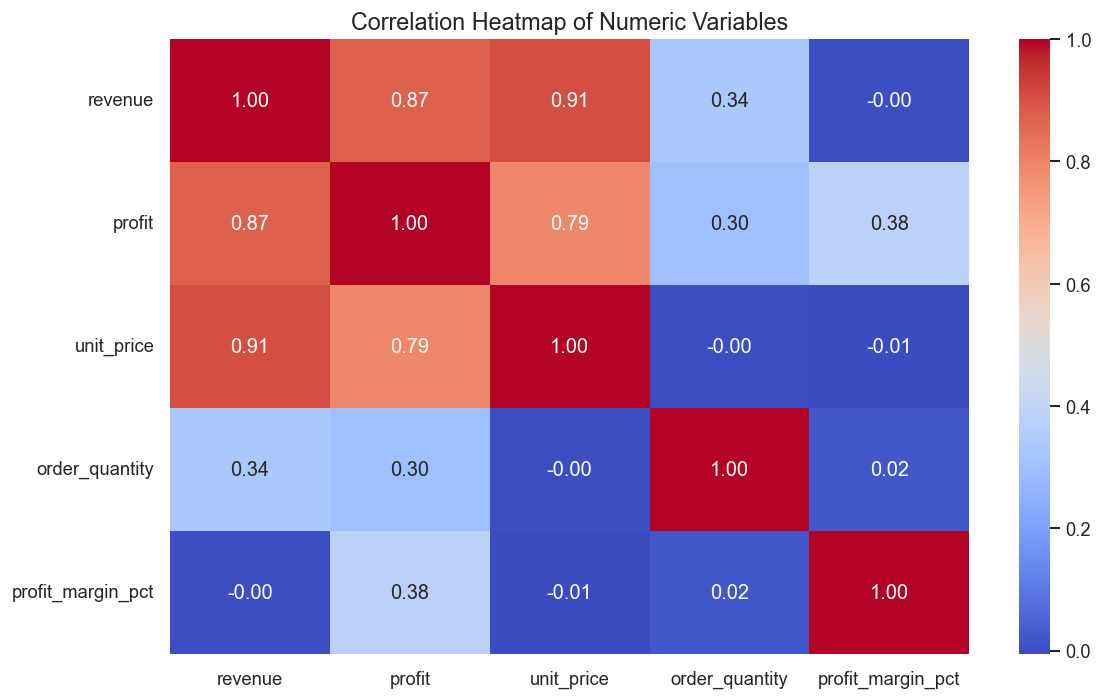

In [258]:
plt.figure(figsize=(10,6))
corr = df_copy2[['revenue', 'profit', 'unit_price', 'order_quantity', 'profit_margin_pct']].corr()

sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Numeric Variables')
plt.tight_layout()
plt.show()


## Key insights 

## 📊 Key Business Insights from EDA

### 1. 🗓️ Monthly Revenue Seasonality
May records the highest revenue across all months, indicating a strong seasonal sales spike — possibly due to end-of-quarter demand or promotions.

---

### 2. 📦 Top 10 Products by Performance
A small set of top 10 products contribute the majority of both revenue and profit, following the Pareto principle. These products should be prioritized for promotions and inventory optimization.

---

### 3. 💰 Revenue vs Profit Relationship
Revenue and profit show a positive correlation, but not always in sync. Some high-revenue orders yield low profit margins due to higher associated costs, highlighting the need to optimize for profitability.

---

### 4. 🔄 Sales Distribution by Channel
- **Wholesale**: 54.1% of total sales  
- **Distributor**: 31.3%  
- **Export**: 14.6%  
Wholesale is the dominant sales channel, though export—despite its smaller share—may offer better margins and should be monitored for growth potential.

---

### 5. 🌍 Sales Distribution by Region
- **West**: 30.1% of total revenue  
- **South**: 27.1%  
- **Midwest**: 25%  
- **Northeast**: 16.8%  
The West and South regions are the most profitable, suggesting high market potential and opportunities for further investment.

---

### 6. 🧑‍💼 Customer Revenue Extremes
The top 10 customers generate significantly more revenue than the bottom 10. This emphasizes the importance of key account management and loyalty programs, while also identifying low-performing customers for potential re-engagement.
